In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from torch.utils.data import Dataset, DataLoader
from source.model.memory import HebbianMemory
from source.utils import get_sequence, DatasetConverter
import matplotlib.pyplot as plt

In [678]:
torch.manual_seed(0)
random.seed(0)

n_members = 5
vocab_size = 2*n_members + 1
seq_len = 3
hidden_size = 100
num_epochs = 100
total_samples = 100

model = HebbianMemory(vocab_size=vocab_size,hidden_size=hidden_size, alpha_init=.9, eta=.01, topk=30)

sequence = get_sequence(total_samples, 2, n_members, train_percent=1.0/n_members)
dataset = DatasetConverter(sequence, short_term_memory=1)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

hidden_codes = []
labels = []
total = 0
for x,y in loader:
    _, h = model(x)

    total += 1
    if total > 20:
        hidden_codes.append(h.squeeze(0).numpy())

        s = ''
        for d in x[0]:
            s += chr(d+ord('A'))
        labels.append(s)


hidden_codes = torch.tensor(hidden_codes)

In [679]:
hidden_codes

tensor([[ 0.8080,  0.0000,  0.0000,  ...,  0.0000,  0.8200,  0.0000],
        [ 0.0000, -0.8489,  0.0000,  ...,  0.0000,  0.0000,  0.9098],
        [-0.9928, -0.9636,  0.0000,  ...,  0.0000,  0.0000,  0.8545],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ..., -0.7223,  0.0000,  0.0000],
        [-0.7574,  0.0000,  0.0000,  ..., -0.7211,  0.0000,  0.0000],
        [-0.8977,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])

MDS stress: 6991.560256152348


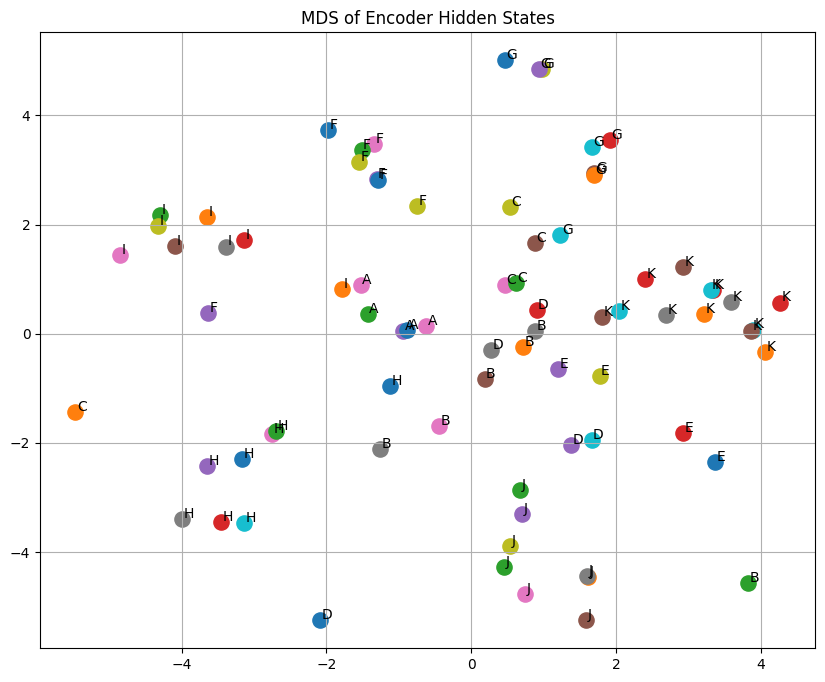

In [680]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import itertools


# Step 1: MDS projection
mds = MDS(
    n_components=2,
    random_state=420,
    dissimilarity="euclidean",  # uses Euclidean distances on hidden_codes
    normalized_stress="auto"
)

embeddings = mds.fit_transform(hidden_codes)

# Optional: report stress (lower is better)
print("MDS stress:", mds.stress_)

# Step 2: Plot
plt.figure(figsize=(10, 8))
for i, txt in enumerate(labels):
    plt.scatter(embeddings[i, 0], embeddings[i, 1], s=120)
    plt.text(
        embeddings[i, 0] + 0.02,
        embeddings[i, 1] + 0.02,
        txt,
        fontsize=10
    )

plt.title("MDS of Encoder Hidden States")
plt.grid(True)
plt.show()


In [681]:
hidden_codes[:, 25]

tensor([ 0.7594,  0.9506,  0.9283,  0.0000,  0.8815,  0.0000,  0.8624, -0.8927,
         0.0000,  0.0000,  0.8628,  0.0000,  0.8886, -0.8774,  0.0000,  0.0000,
         0.8540,  0.0000,  0.9061, -0.8637,  0.0000,  0.0000,  0.8589,  0.0000,
         0.0000,  0.8148,  0.0000,  0.0000,  0.8330,  0.0000,  0.0000,  0.8128,
         0.0000,  0.0000,  0.8254,  0.0000,  0.0000,  0.8014,  0.0000,  0.0000,
         0.8158,  0.0000,  0.0000,  0.7927,  0.0000,  0.0000,  0.0000,  0.8569,
         0.9124,  0.8407,  0.0000,  0.0000,  0.0000,  0.0000,  0.8503,  0.9287,
         0.8987,  0.0000,  0.8396,  0.0000,  0.0000,  0.8229,  0.0000,  0.0000,
         0.0000,  0.8497,  0.8886,  0.8243,  0.0000,  0.0000,  0.0000,  0.8432,
         0.8793,  0.8220,  0.7388,  0.0000,  0.0000,  0.8510])

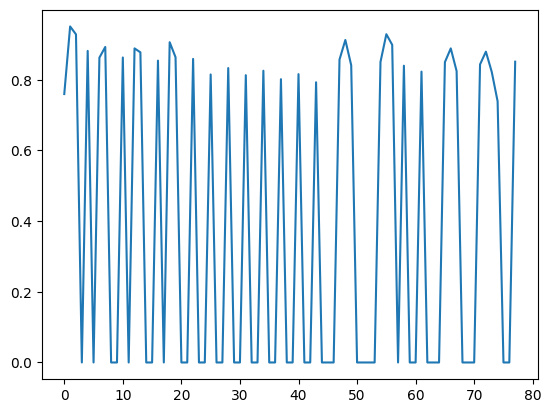

In [682]:
import numpy as np 

plt.plot(torch.abs(hidden_codes[:,25]))

In [683]:
hidden_codes[12,:]

tensor([-0.8978,  0.0000,  0.0000,  0.0000,  0.0000,  0.8832, -0.9938,  0.0000,
         0.0000,  0.0000,  0.9480,  0.0000,  0.0000,  0.9586, -0.8927,  0.0000,
         0.0000, -0.9464,  0.0000,  0.0000, -0.9842,  0.0000,  0.0000,  0.0000,
         0.0000,  0.8886,  0.0000,  0.9424, -0.9652,  0.0000, -0.9119,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000, -0.8013,  0.0000,  0.0000,  0.0000, -0.8254,
        -0.8623,  0.0000,  0.0000,  0.9453,  0.0000,  0.7850, -0.8513,  0.0000,
         0.0000,  0.9390, -0.7613,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.9927,  0.0000,  0.0000,  0.0000,  0.0000,  0.8437,  0.0000, -0.8016,
         0.0000,  0.0000,  0.0000,  0.0000, -0.7535,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.9856, -0.8452,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000, -0.8830, -0.8923,  0.9039,  0.0000,
         0.0000,  0.0000,  0.7844,  0.00

In [684]:
hidden_codes[13,:]

tensor([ 0.9144, -0.9871,  0.0000,  0.0000,  0.0000,  0.8004,  0.8358, -0.9149,
         0.0000, -0.8383,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.9539,
         0.0000, -0.9127,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000, -0.8774,  0.8797,  0.0000, -0.9738,  0.0000,  0.7909,  0.0000,
         0.0000,  0.0000,  0.9766,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.9791,  0.0000,  0.0000,  0.0000, -0.8275,  0.0000,
         0.0000,  0.0000,  0.8783,  0.0000, -0.9729,  0.0000,  0.8796,  0.9047,
         0.0000,  0.9378,  0.0000,  0.0000,  0.0000, -0.9456,  0.0000,  0.0000,
         0.0000,  0.9789,  0.0000,  0.0000,  0.0000,  0.0000,  0.8312,  0.0000,
         0.9423,  0.0000, -0.9569,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000, -0.9332, -0.8062,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000, -0.8438, -0.8909,  0.0000,  0.0000,  0.0000,  0.0000,
         0.8497,  0.0000,  0.0000,  0.00

In [685]:
model.parameters

<bound method Module.parameters of HebbianMemory(
  (embedding): Embedding(11, 100)
)>

In [686]:
model.A

tensor([[[ 0.0306,  0.0364,  0.0124,  ...,  0.0290,  0.0039, -0.0025],
         [ 0.0631, -0.0351, -0.0134,  ...,  0.0100, -0.0185, -0.0093],
         [ 0.0185, -0.0221, -0.0052,  ..., -0.0054,  0.0000,  0.0000],
         ...,
         [ 0.0646,  0.0156,  0.0122,  ...,  0.0266,  0.0083, -0.0027],
         [-0.0066, -0.0155,  0.0000,  ...,  0.0061, -0.0056,  0.0035],
         [-0.0015, -0.0070,  0.0000,  ..., -0.0036,  0.0028,  0.0066]]],
       grad_fn=<AddBackward0>)